# Project 2: Exploratory Data Analysis (EDA)


## Step 1: Upload CSV file

In [1]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_data.csv to cleaned_data.csv


## Step 2: Load the data

In [2]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Rows:", len(df))
df.head()

Rows: 1200


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Step 3: Basic statistics

In [3]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


## Step 4: Mean vs Median



In [5]:
mean_value = df['TotalPrice'].mean()
median_value = df['TotalPrice'].median()

print("Mean:", round(mean_value, 2))
print("Median:", round(median_value, 2))


Mean: 1053.97
Median: 823.62


## Step 5: Visualize the distribution (histogram)

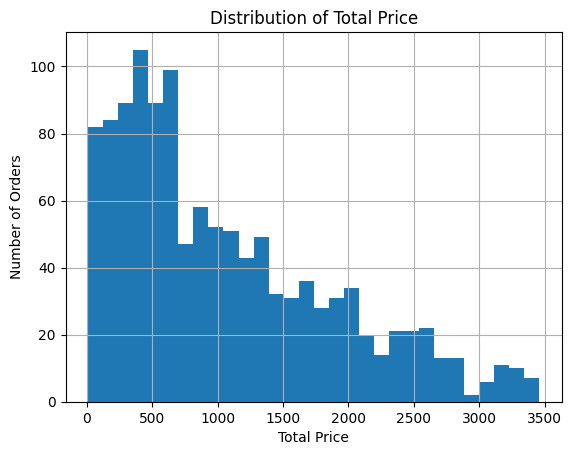

In [6]:
import matplotlib.pyplot as plt

df['TotalPrice'].hist(bins=30)
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Number of Orders')
plt.show()

## Step 6: Find outliers with a boxplot

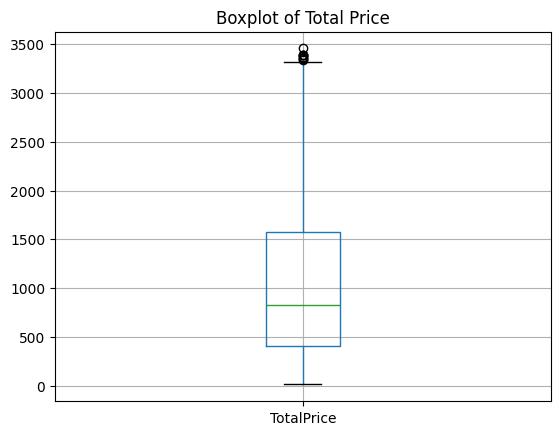

In [8]:
df.boxplot(column='TotalPrice')
plt.title('Boxplot of Total Price')
plt.show()

# The dots above/below the whiskers are outliers

## Step 7: Group and compare categories

In [9]:
# Total revenue per product, sorted highest to lowest
# Change 'Product' and 'TotalPrice' to match the dataset
revenue_by_product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
revenue_by_product

,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


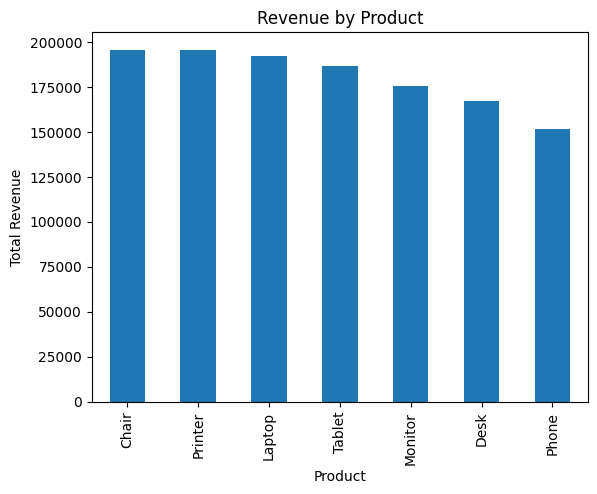

In [10]:
revenue_by_product.plot(kind='bar')
plt.title('Revenue by Product')
plt.ylabel('Total Revenue')
plt.show()

## Step 8: Count categories

In [11]:
# How many orders fall into each status?
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


## Step 9: Check relationships between numbers (correlation)

In [12]:
# A correlation close to 1 means two columns move up/down together.
# Close to 0 means no relationship. Close to -1 means opposite directions.
df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,0.014553,0.615251
UnitPrice,0.014553,1.000000,0.717081
TotalPrice,0.615251,0.717081,1.000000
